In [1]:
# Import the libraries.
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from shapely.geometry import shape

In [2]:
# Load the original Street Addresses CSV file.
street_raw = pd.read_csv("street-addresses.csv")

In [3]:
# Create a working copy so the original dataset remains unchanged.
street = street_raw.copy()

In [4]:
# Define a function to check size, columns, data types, missing values and duplicate rows.
def check_dataframe(df, name):
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    
    # Preview the first five rows.
    display(df.head())

    # Check the data type of each column.
    print("\nData types:")
    display(df.dtypes.to_frame("data_type"))

    # Check missing values in each column.
    print("\nMissing values:")
    missing = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percentage": (df.isna().mean() * 100).round(2)
    })

    display(missing.sort_values("missing_percentage", ascending=False))

    # Count identical rows.
    print("\nDuplicate rows:", df.duplicated().sum())

In [5]:
# Check the street-address dataset.
check_dataframe(street, "Street Addresses")

Shape: 63,721 rows × 14 columns


,Geo Point,Geo Shape,suburb_id,latitude,street_no,str_name,address_pnt,easting,northing,gisid,longitude,suburb,street_id,add_comp
0,"-37.81372270083, 144.942360371101","{""coordinates"": [144.942360371101, -37.8137227...",599.0,-37.813723,2,Marmion Place,2 Marmion Place Docklands,318878.970914,5.812858e+06,43454,144.942360,Docklands,120059,NaN
1,"-37.834473648712, 144.985830959086","{""coordinates"": [144.985830959086, -37.8344736...",595.0,-37.834474,238,Domain Road,238 Domain Road South Yarra,322755.472097,5.810639e+06,61751,144.985831,South Yarra,572,NaN
2,"-37.824543614626, 144.947497406914","{""coordinates"": [144.947497406914, -37.8245436...",599.0,-37.824544,56,River Esplanade,56 River Esplanade Docklands,319357.587006,5.811667e+06,2219,144.947497,Docklands,117906,NaN
3,"-37.803653518127, 144.96621988202","{""coordinates"": [144.96621988202, -37.80365351...",585.0,-37.803654,1,Argyle Place South,1 Argyle Place South Carlton,320955.071726,5.814021e+06,12492,144.966220,Carlton,398,NaN
4,"-37.778285397495, 144.941832527766","{""coordinates"": [144.941832527766, -37.7782853...",593.0,-37.778285,70,Parkville Avenue,70 Parkville Avenue Parkville,318745.896096,5.816789e+06,21054,144.941833,Parkville,119271,NaN



Data types:


,data_type
Geo Point,object
Geo Shape,object
suburb_id,float64
latitude,float64
street_no,object
str_name,object
address_pnt,object
easting,float64
northing,float64
gisid,int64



Missing values:


,missing_count,missing_percentage
add_comp,62369,97.88
suburb,730,1.15
street_no,652,1.02
suburb_id,6,0.01
Geo Shape,0,0.00
Geo Point,0,0.00
str_name,1,0.00
latitude,0,0.00
address_pnt,0,0.00
easting,0,0.00



Duplicate rows: 0


In [6]:
# Data Cleaning and Validation
# Define a function to standardise the column names of a dataset.
def standardise_column_names(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )

    return df

In [7]:
# Standardise the street-address column names.
street = standardise_column_names(street)

In [8]:
# Display the standardised column names for checking.
print(street.columns.tolist())

['geo_point', 'geo_shape', 'suburb_id', 'latitude', 'street_no', 'str_name', 'address_pnt', 'easting', 'northing', 'gisid', 'longitude', 'suburb', 'street_id', 'add_comp']


In [9]:
# Check whether gisid is a valid unique identifier.
street_identifier_check = {
    "total_rows": len(street),
    "missing_gisid": street["gisid"].isna().sum(),
    "duplicated_gisid": street["gisid"].dropna().duplicated().sum()
}

display(street_identifier_check)

{'total_rows': 63721,
 'missing_gisid': np.int64(0),
 'duplicated_gisid': np.int64(0)}

In [10]:
# Check missing values after type conversion.
display(street[["suburb_id", "gisid", "street_id"]].isna().sum())

suburb_id    6
gisid        0
street_id    0
dtype: int64

In [11]:
# Check street-address records with missing suburb information.
missing_suburb_sample = street.loc[
    street["suburb"].isna(),
    [
        "gisid",
        "street_no",
        "str_name",
        "address_pnt",
        "suburb_id",
        "latitude",
        "longitude"
    ]
]

display(missing_suburb_sample.head(30))

,gisid,street_no,str_name,address_pnt,suburb_id,latitude,longitude
19,23270,96,Garton Street,96 Garton Street,0.0,-37.782276,144.964145
60,36951,139,Normanby Road,139 Normanby Road,0.0,-37.827948,144.952070
72,23061,915,Park Street,915 Park Street,0.0,-37.775893,144.943508
165,23574,165,Epsom Road,165 Epsom Road,0.0,-37.784765,144.918871
230,23395,810,Lygon Street,810 Lygon Street,0.0,-37.787064,144.969463
382,33685,16,Langs Road,16 Langs Road,0.0,-37.781252,144.910225
396,23486,114,Princes Street,114 Princes Street,0.0,-37.792498,144.971853
405,23178,883,Park Street,883 Park Street,0.0,-37.776297,144.946855
417,36947,131,Normanby Road,131 Normanby Road,0.0,-37.827981,144.952403
488,23250,38,Garton Street,38 Garton Street,0.0,-37.783967,144.963873


In [12]:
# Check addresses without a conventional street number.
missing_street_number = street.loc[
    street["street_no"].isna(),
    [
        "gisid",
        "str_name",
        "address_pnt",
        "suburb",
        "latitude",
        "longitude"
    ]
]

display(missing_street_number.head(30))

,gisid,str_name,address_pnt,suburb,latitude,longitude
122,41214,Flinders Street Station Concourse,Flinders Street Station Concourse Melbourne,Melbourne,-37.818258,144.967230
123,46413,Dock Link Road,Northern Port Roads Dock Link Road West Melbo...,West Melbourne,-37.809020,144.915738
137,39646,Grattan Street,"Shop 75, Ground Union House Building 130, Univ...",Parkville,-37.796961,144.960926
290,19238,Block Arcade,Shop 15 Block Arcade Melbourne,Melbourne,-37.815574,144.964102
385,43112,Boathouse Drive,Yarra Boathouses Boathouse Drive Melbourne,Melbourne,-37.819729,144.970226
536,42342,River Esplanade,"Berth 83, Marina YE River Esplanade Docklands",Docklands,-37.823842,144.944714
561,2537,Swanson Dock West,Berth 2 Swanson Dock West West Melbourne,West Melbourne,-37.814942,144.912357
838,42619,Toorak Road,Toorak & St Kilda Road Reserve Toorak Road Me...,Melbourne,-37.836827,144.976199
1024,47420,QV Square,ATM 3 QV Square Melbourne,Melbourne,-37.810348,144.965639
1055,42393,River Esplanade,"Berth 45, Marina YE River Esplanade Docklands",Docklands,-37.823709,144.946281


In [13]:
# Check records with a missing street name or suburb ID.
display(street.loc[street["str_name"].isna()])

display(
    street.loc[
        street["suburb_id"].isna(),
        [
            "gisid",
            "street_no",
            "str_name",
            "address_pnt",
            "suburb",
            "latitude",
            "longitude"
        ]
    ]
)

,geo_point,geo_shape,suburb_id,latitude,street_no,str_name,address_pnt,easting,northing,gisid,longitude,suburb,street_id,add_comp
40166,"-37.796995386122, 144.950000442022","{""coordinates"": [144.950000442022, -37.7969953...",592.0,-37.796995,5,NaN,5 North Melbourne,319510.823247,5.814729e+06,46813,144.95,North Melbourne,2931,NaN


,gisid,street_no,str_name,address_pnt,suburb,latitude,longitude
5889,37295,128,Normanby Road,128 Normanby Road,NaN,-37.827506,144.952641
16807,37296,130,Normanby Road,130 Normanby Road,NaN,-37.827525,144.952561
18436,37293,124,Normanby Road,124 Normanby Road,NaN,-37.827467,144.952801
29920,36432,50,Normanby Road,50 Normanby Road,NaN,-37.825995,144.955261
31543,37294,126,Normanby Road,126 Normanby Road,NaN,-37.827486,144.952721
56644,36433,52,Normanby Road,52 Normanby Road,NaN,-37.826040,144.955198


In [14]:
# Validate the street-address coordinates.
# Split geo_point into latitude and longitude.
geo_point_split = street["geo_point"].str.split(
    ",",
    n=1,
    expand=True
)

geo_point_latitude = pd.to_numeric(
    geo_point_split[0].str.strip(),
    errors="coerce"
)

geo_point_longitude = pd.to_numeric(
    geo_point_split[1].str.strip(),
    errors="coerce"
)

# Calculate differences between the two coordinate representations.
latitude_difference = (
    street["latitude"] - geo_point_latitude
).abs()

longitude_difference = (
    street["longitude"] - geo_point_longitude
).abs()

# Identify differences greater than the selected tolerance.
coordinate_tolerance = 0.000001

coordinate_mismatches = street[
    (latitude_difference > coordinate_tolerance) |
    (longitude_difference > coordinate_tolerance)
]

# Check whether coordinates are within the selected Melbourne-area range.
invalid_coordinates = street[
    ~street["latitude"].between(-39.5, -37.0) |
    ~street["longitude"].between(143.0, 146.5)
]

# Display the validation results.
print("Maximum latitude difference:", latitude_difference.max())
print("Maximum longitude difference:", longitude_difference.max())
print("Coordinate mismatches:", len(coordinate_mismatches))
print("Potentially invalid coordinates:", len(invalid_coordinates))
print(
    "Rows with missing coordinates:",
    street[
        ["latitude", "longitude", "geo_point"]
    ].isna().any(axis=1).sum()
)

Maximum latitude difference: 5.442998940452526e-09
Maximum longitude difference: 5.555989446293097e-09
Coordinate mismatches: 0
Potentially invalid coordinates: 0
Rows with missing coordinates: 0


In [15]:
# Clean the street-address text fields.
street_text_columns = [
    "street_no",
    "str_name",
    "address_pnt",
    "suburb",
    "add_comp"
]

for column in street_text_columns:
    street[column] = (
        street[column]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

# Convert identifier fields to nullable integers.
for column in ["suburb_id", "gisid", "street_id"]:
    street[column] = (
        pd.to_numeric(street[column], errors="coerce")
        .astype("Int64")
    )

In [16]:
# Add data-quality flags after cleaning the text fields.
street["missing_street_number_flag"] = street["street_no"].isna()
street["missing_street_name_flag"] = street["str_name"].isna()
street["missing_suburb_flag"] = street["suburb"].isna()
street["missing_suburb_id_flag"] = street["suburb_id"].isna()

street["address_completeness"] = np.where(
    street[["street_no", "str_name", "suburb"]]
    .notna()
    .all(axis=1),
    "Complete",
    "Partial"
)

In [17]:
# Convert GeoJSON values to Shapely geometry.
def parse_geojson_geometry(value):
    if pd.isna(value):
        return None

    try:
        geojson_object = (
            json.loads(value)
            if isinstance(value, str)
            else value
        )

        return shape(geojson_object)

    except (
        json.JSONDecodeError,
        TypeError,
        ValueError,
        KeyError
    ):
        return None


# Parse the street-address GeoJSON geometry.
street["geometry"] = street["geo_shape"].apply(
    parse_geojson_geometry
)

# Convert the DataFrame to a GeoDataFrame.
street_gdf = gpd.GeoDataFrame(
    street.copy(),
    geometry="geometry",
    crs="EPSG:4326"
)

# Identify geometry-quality issues.
missing_geometry = street_gdf.geometry.isna()

empty_geometry = (
    street_gdf.geometry.notna()
    & street_gdf.geometry.is_empty
)

invalid_geometry = (
    street_gdf.geometry.notna()
    & ~street_gdf.geometry.is_empty
    & ~street_gdf.geometry.is_valid
)

parsing_failure = (
    street["geo_shape"].notna()
    & street["geometry"].isna()
)

# Summarise geometry quality.
street_geometry_quality = pd.Series({
    "total_records": len(street_gdf),
    "missing_geometry": missing_geometry.sum(),
    "parsing_failures": parsing_failure.sum(),
    "empty_geometry": empty_geometry.sum(),
    "invalid_geometry": invalid_geometry.sum()
})

print("Street Addresses geometry types:")
display(
    street_gdf.geometry
    .apply(
        lambda geometry: (
            geometry.geom_type
            if geometry is not None
            else "Missing"
        )
    )
    .value_counts()
)

display(street_geometry_quality)

Street Addresses geometry types:


geometry
Point    63721
Name: count, dtype: int64

total_records       63721
missing_geometry        0
parsing_failures        0
empty_geometry          0
invalid_geometry        0
dtype: int64

In [18]:
# Create the final cleaned Street Addresses GeoDataFrame.
street_clean = street_gdf.copy()

# Project the geometry to a CRS that uses metres.
PROJECTED_CRS = "EPSG:7855"
street_projected = street_clean.to_crs(PROJECTED_CRS)

In [19]:
# Summarise address records by suburb.
street_suburb_summary = (
    street_clean["suburb"]
    .fillna("Suburb not supplied")
    .value_counts()
    .rename_axis("suburb")
    .reset_index(name="address_count")
)

display(street_suburb_summary)

,suburb,address_count
0,Melbourne,14894
1,North Melbourne,8524
2,Kensington,7809
3,Carlton,7402
4,West Melbourne,5341
5,Docklands,3786
6,East Melbourne,3591
7,Parkville,3294
8,Southbank,2835
9,South Yarra,2834


In [20]:
# Summarise address completeness.
address_completeness_summary = (
    street_clean["address_completeness"]
    .value_counts()
    .rename_axis("address_completeness")
    .reset_index(name="address_count")
)

display(address_completeness_summary)

,address_completeness,address_count
0,Complete,62338
1,Partial,1383


In [21]:
# Create separate folders for Street Addresses outputs.
OUTPUT_DIR = Path("outputs/street_addresses")
CLEANED_DIR = OUTPUT_DIR / "cleaned_data"
FIGURE_DIR = OUTPUT_DIR / "figures"

CLEANED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# Save, display and close a figure.
def save_and_show_figure(filename):
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

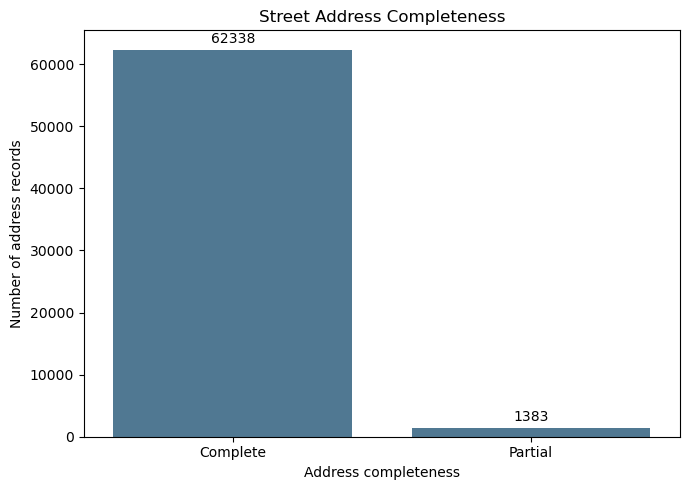

In [22]:
# Visualise address completeness.
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=address_completeness_summary,
    x="address_completeness",
    y="address_count",
    color="#457B9D",
    errorbar=None
)

ax.set_title("Street Address Completeness")
ax.set_xlabel("Address completeness")
ax.set_ylabel("Number of address records")

ax.bar_label(
    ax.containers[0],
    fmt="%.0f",
    padding=3
)

save_and_show_figure(
    "street_address_completeness.png"
)

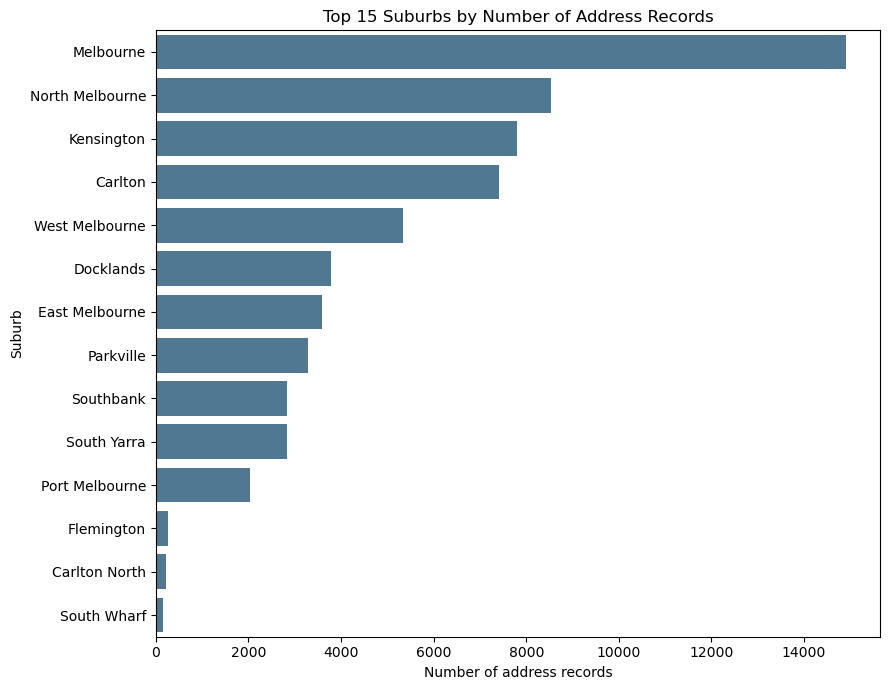

In [23]:
# Select the 15 suburbs with the most address records.
top_suburbs = (
    street_suburb_summary
    .loc[
        street_suburb_summary["suburb"]
        != "Suburb not supplied"
    ]
    .head(15)
)

# Visualise address counts by suburb.
plt.figure(figsize=(9, 7))

ax = sns.barplot(
    data=top_suburbs,
    x="address_count",
    y="suburb",
    color="#457B9D",
    errorbar=None
)

ax.set_title("Top 15 Suburbs by Number of Address Records")
ax.set_xlabel("Number of address records")
ax.set_ylabel("Suburb")

save_and_show_figure(
    "street_addresses_by_suburb.png"
)

In [24]:
# Export the cleaned Street Addresses dataset.
street_export = (
    street_clean
    .drop(columns="geometry")
    .copy()
)

street_export.to_csv(
    CLEANED_DIR / "street_addresses_cleaned.csv",
    index=False
)

# Export the Street Addresses summary tables.
street_suburb_summary.to_csv(
    CLEANED_DIR / "street_addresses_suburb_summary.csv",
    index=False
)

address_completeness_summary.to_csv(
    CLEANED_DIR / "address_completeness_summary.csv",
    index=False
)

In [25]:
# Confirm that the expected Street Addresses files were created.
expected_output_files = [
    "street_addresses_cleaned.csv",
    "street_addresses_suburb_summary.csv",
    "address_completeness_summary.csv"
]

for filename in expected_output_files:
    output_path = CLEANED_DIR / filename

    assert output_path.exists()

    print(f"Exported: {output_path}")

Exported: outputs/street_addresses/cleaned_data/street_addresses_cleaned.csv
Exported: outputs/street_addresses/cleaned_data/street_addresses_suburb_summary.csv
Exported: outputs/street_addresses/cleaned_data/address_completeness_summary.csv


## Key Findings

- The Street Addresses dataset contained 63,721 records and no exact duplicate rows.
- The `gisid` field contained no missing or duplicated values and was retained as the unique record identifier.
- All 63,721 GeoJSON geometries were successfully parsed as Point geometries. No missing, empty or invalid geometries were identified.
- A total of 652 records did not contain a conventional street number, 730 records did not contain a supplied suburb name, six records had a missing suburb ID, and one record had a missing street name.
- The `add_comp` field was missing in 62,369 records. It was retained because it is an optional address-component field rather than a required identifier.
- The latitude and longitude values matched the coordinates stored in `geo_point` within the selected numerical tolerance.

## Limitations

- The dataset covers property addresses within the City of Melbourne rather than the whole Greater Melbourne region. The results cannot be applied directly to areas outside the City of Melbourne, including Lilydale.
- Some records do not contain a conventional street number or supplied suburb name. These records were retained and identified using data-quality flags.
- The high missing percentage in `add_comp` does not necessarily indicate an invalid address because the field contains optional additional address information.
- The analysis evaluates address-data completeness and spatial validity only. It does not assess drainage conditions, water movement or flood risk.